# Librerías

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from urllib.request import urlopen
from skimage.feature import hog
from skimage import exposure
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Conjunto de datos

Se construyó un conjunto de datos compuesto por 40 imágenes, distribuidas en dos clases: 20 correspondientes a sentadillas y 20 a flexiones de pecho. Las imágenes fueron seleccionadas optando por incluir variaciones en la posición del cuerpo, el ángulo de captura y la perspectiva, con el fin de representar el movimiento desde diferentes direcciones. Esto permite capturar una mayor diversidad de características visuales y mejorar la capacidad del modelo frente a distintas condiciones.

In [2]:
def center_crop(img, crop_ratio=0.75):
    """
    Recorta la región central de la imagen.
    crop_ratio: fracción del ancho/alto a conservar (0.75 = 75% central)
    """
    h, w = img.shape[:2]
    new_h = int(h * crop_ratio)
    new_w = int(w * crop_ratio)
    y1 = (h - new_h) // 2
    x1 = (w - new_w) // 2
    return img[y1:y1+new_h, x1:x1+new_w]

Total imágenes: 40


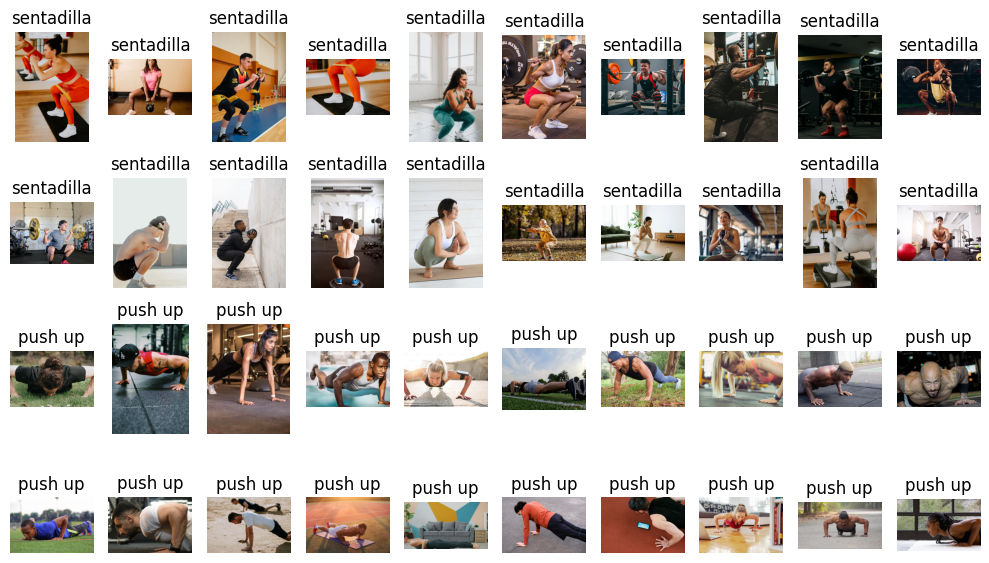

In [3]:
np.random.seed(42)

# (puede cambiar/añadir)
sentadillas = [
    "https://plus.unsplash.com/premium_photo-1666736569069-79c1789adf52?q=80&w=688&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1603503363848-6952525df449?q=80&w=1169&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1675364965052-fdb98d1ddd67?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1666736569066-1b51689fac70?q=80&w=1169&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1649887974297-4be052375a67?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1718633561231-864a4c466991?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8NTd8fGFpciUyMHNxdWF0fGVufDB8fDB8fHww",
    "https://images.unsplash.com/photo-1541600383005-565c949cf777?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTExfHxhaXIlMjBzcXVhdHxlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1646072508462-a802209a16f3?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTE0fHxhaXIlMjBzcXVhdHxlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1654906546323-ceb7ee0d699b?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTY0fHxhaXIlMjBzcXVhdHxlbnwwfHwwfHx8MA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1665203477453-0a9d0e0ae2b0?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1513352098199-8ccf457b35a8?q=80&w=1074&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1649878974657-81fd06097742?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1661438165787-dca9da5b88e2?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8OTd8fGhvbWJyZSUyMGhhY2llbmRvJTIwYWlyJTIwc3F1YXR8ZW58MHx8MHx8fDA%3D",
    "https://plus.unsplash.com/premium_photo-1663134028905-17e4b80c5162?q=80&w=679&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1767611118992-b300c4fb4bee?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTE3fHxzZW50YWRpbGxhfGVufDB8fDB8fHww",
    "https://media.istockphoto.com/id/2193062720/es/foto/un-viejo-deportista-activo-haciendo-sentadillas-en-la-naturaleza.webp?a=1&b=1&s=612x612&w=0&k=20&c=dxdIIAru61IAZ_qdF0K7R5gdN4QlbS0O7mQDVycU9M0=",
    "https://media.istockphoto.com/id/2206452955/es/foto/joven-mujer-asi%C3%A1tica-hermosa-haciendo-ejercicio-aer%C3%B3bico-en-casa-chica-atractiva-haciendo.webp?a=1&b=1&s=612x612&w=0&k=20&c=BFomBm9ez5V99pUq3SyZZbVrwrpJTiowEMNfs4WBXO0=",
    "https://media.istockphoto.com/id/2216625500/es/foto/atleta-femenina-feliz-haciendo-sentadillas-mientras-entrena-con-pesas-en-un-gimnasio.webp?a=1&b=1&s=612x612&w=0&k=20&c=-PJVqlPGSCoiHRPGeHgPfRbRiKjb1eVNjBuMOOen0B8=",
    "https://plus.unsplash.com/premium_photo-1666736569549-c106f7921d87?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8OTJ8fHNlbnRhZGlsbGF8ZW58MHx8MHx8fDA%3D",
    "https://plus.unsplash.com/premium_photo-1663134039867-4c39cb97fe65?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTY0fHxzZW50YWRpbGxhfGVufDB8fDB8fHww"
]

flexionpecho = [
    "https://plus.unsplash.com/premium_photo-1664538541993-762eb39c6b40?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1598971639058-fab3c3109a00?q=80&w=701&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1718633625616-e5f297177a26?q=80&w=736&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1616803689943-5601631c7fec?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1663036507091-5d37013776c2?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1638820858482-800bd51f63f1?q=80&w=1074&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1683192943220-d191b72a4fac?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1661382496028-31fcde90200f?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1666956838556-f940185abbbf?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1621787280498-d8140600df44?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Nzd8fHB1c2glMjB1cHxlbnwwfHwwfHx8Mg%3D%3D",
    "https://images.unsplash.com/photo-1600677396341-16965cbe9224?q=80&w=1169&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1764426445448-95103b0024a6?q=80&w=1167&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://images.unsplash.com/photo-1540474211005-7c8a448f69e6?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8ODV8fHB1c2glMjB1cHxlbnwwfHwwfHx8Mg%3D%3D",
    "https://plus.unsplash.com/premium_photo-1663012894269-7a0840cc108a?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTA1fHxwdXNoJTIwdXBzJTIwdmlzdGElMjBkZXNkZSUyMGFycmliYXxlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1758599878868-52cced2f8154?q=80&w=1332&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1673210887551-1b3dac70ef6d?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1712762001147-7f3d8bff3002?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MjY0fHxmbGV4aW9uJTIwZGUlMjBwZWNob3xlbnwwfHwwfHx8MA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1663045350901-80e9577dbaa8?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MTk5fHxmbGV4aW9uJTIwZGUlMjBwZWNob3xlbnwwfHwwfHx8MA%3D%3D",
    "https://images.unsplash.com/photo-1669614660460-22e8533a03f4?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MjAwfHxmbGV4aW9uJTIwZGUlMjBwZWNob3xlbnwwfHwwfHx8MA%3D%3D",
    "https://plus.unsplash.com/premium_photo-1672784158368-a08c56a44c0b?w=600&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MjYwfHxmbGV4aW9uJTIwZGUlMjBwZWNob3xlbnwwfHwwfHx8MA%3D%3D",
]

CROP_RATIO = 0.75  # ajuste del recorte central (0.75 = 75% central)

images_rgb = []
labels = []

for url in sentadillas + flexionpecho:
    img_bytes = urlopen(url).read()
    img_bgr  = cv2.imdecode(np.frombuffer(img_bytes, np.uint8), cv2.IMREAD_COLOR)
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_crop = center_crop(img_rgb, crop_ratio=CROP_RATIO)   # ← aquí
    images_rgb.append(img_crop)
    labels.append("sentadilla" if url in sentadillas else "push up")

print(f"Total imágenes: {len(images_rgb)}")
plt.figure(figsize=(10,6))

for i in range(len(images_rgb)):
    plt.subplot(4, 10, i+1)
    plt.imshow(images_rgb[i])
    plt.title(labels[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Visualizar comparación antes / después del crop

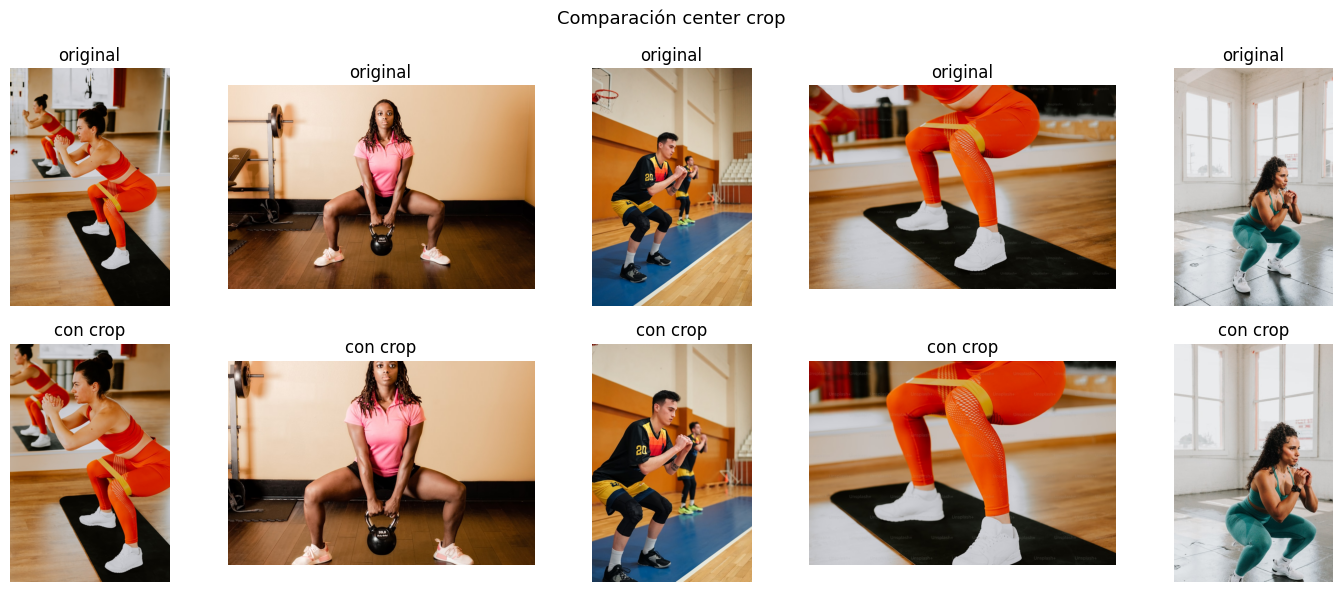

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# fila superior = originales, fila inferior = con crop
for i in range(5):
    url = (sentadillas + flexionpecho)[i]
    img_bytes = urlopen(url).read()
    img_bgr   = cv2.imdecode(np.frombuffer(img_bytes, np.uint8), cv2.IMREAD_COLOR)
    img_orig  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_crop  = center_crop(img_orig, crop_ratio=CROP_RATIO)

    axes[0, i].imshow(img_orig);  axes[0, i].set_title("original"); axes[0, i].axis("off")
    axes[1, i].imshow(img_crop);  axes[1, i].set_title("con crop");  axes[1, i].axis("off")

plt.suptitle("Comparación center crop", fontsize=13)
plt.tight_layout()
plt.show()


# Extracción de características

## SIFT

Es un algoritmo utilizado para detectar y describir características locales en imágenes. Su principal ventaja es que las características extraídas son invariantes, lo que significa que el algoritmo puede reconocer el mismo objeto incluso si cambia de tamaño (escala), se rota, cambia la iluminación o se ve desde un ángulo diferente.

Keypoints SIFT por imagen: [739, 997, 755, 613, 587, 1315, 1027, 1299, 561, 967, 2611, 433, 1092, 681, 346, 1894, 437, 532, 779, 611, 3837, 2022, 965, 756, 1971, 2852, 5552, 1027, 1354, 565, 1393, 520, 464, 334, 815, 711, 183, 684, 362, 454]


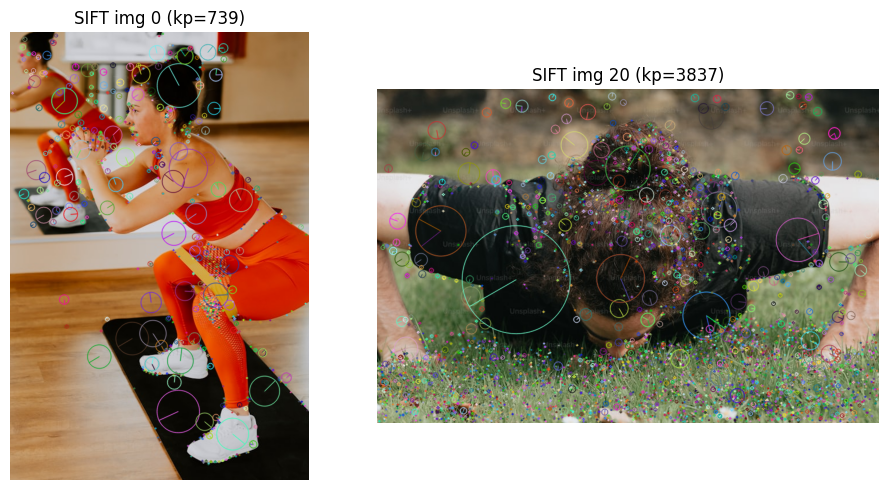

In [5]:
sift = cv2.SIFT_create()

images_gray = []
sift_desc_list = []
n_keypoints = []

for img_rgb in images_rgb:
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    images_gray.append(gray)
    keypoints, descriptors = sift.detectAndCompute(gray, None)

    if descriptors is None:
        descriptors = np.zeros((0, 128), dtype=np.float32)

    sift_desc_list.append(descriptors.astype(np.float32))
    n_keypoints.append(len(keypoints))

print("Keypoints SIFT por imagen:", n_keypoints)

plt.figure(figsize=(10, 5))
for i, idx in enumerate([0, len(images_rgb) // 2]):
    img_kp = cv2.drawKeypoints(
        images_rgb[idx],
        sift.detect(images_gray[idx], None),
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    )
    plt.subplot(1, 2, i + 1)
    plt.imshow(img_kp)
    plt.title(f"SIFT img {idx} (kp={n_keypoints[idx]})")
    plt.axis("off")

plt.tight_layout()
plt.show()

## HOG

HOG (Histogram of Oriented Gradients) divide la imagen en pequeñas celdas y, dentro de cada una, calcula un histograma de las direcciones de los gradientes de intensidad. Estos histogramas se agrupan en bloques y se normalizan para reducir el efecto de cambios de iluminación. El resultado es un descriptor que captura la distribución local de bordes y contornos, siendo especialmente efectivo para representar la forma y la postura del cuerpo humano

Bloques HOG por imagen: [225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225]


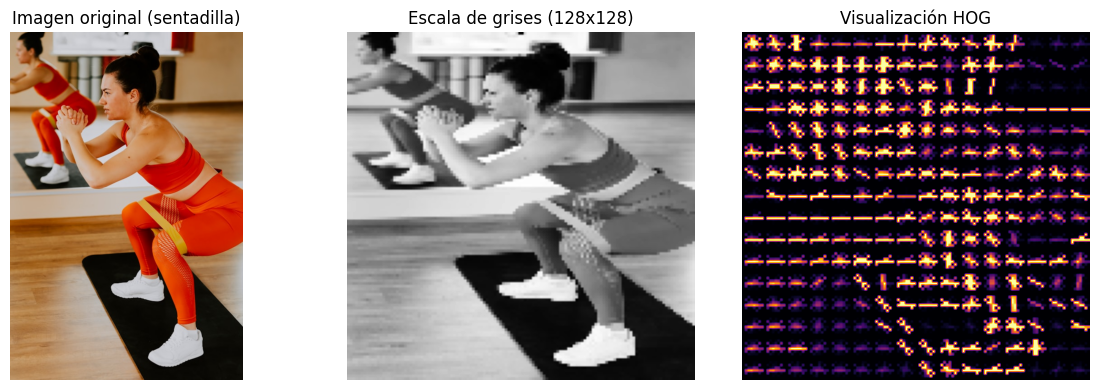

Forma de hog_desc_list[img_idx]: (225, 36)
Longitud del descriptor HOG global: 8100


array([[0.25040007, 0.06633795, 0.25040007, 0.02774603, 0.25040007,
        0.06734516, 0.19108424, 0.25040007, 0.18606865, 0.15581124,
        0.03492322, 0.09733482, 0.08203757, 0.25040007, 0.08775588,
        0.06606124, 0.25040007, 0.17304464, 0.08943255, 0.07561998,
        0.05132135, 0.17555521, 0.24462666, 0.04608318, 0.0570046 ,
        0.04691342, 0.08920935, 0.19397599, 0.25040007, 0.19171706,
        0.13587315, 0.25040007, 0.25040007, 0.14964515, 0.11039274,
        0.14552815],
       [0.11038139, 0.02474066, 0.06895492, 0.05811789, 0.20597984,
        0.06216891, 0.04679978, 0.2761562 , 0.12259004, 0.2761562 ,
        0.02726099, 0.2761562 , 0.20383275, 0.01949115, 0.        ,
        0.00327978, 0.21068616, 0.2761562 , 0.13741843, 0.2761562 ,
        0.13581815, 0.09625664, 0.191138  , 0.2761562 , 0.10601313,
        0.07820555, 0.10309653, 0.01131522, 0.03690566, 0.15762913,
        0.07650378, 0.265984  , 0.24912918, 0.2761562 , 0.12415937,
        0.05588202],
      

In [6]:
orientations = 9
cells_per_block = (2, 2)
hog_size = (128, 128)

hog_images = []
hog_desc_list = []
n_hog_blocks = []

for gray in images_gray:
    gray_resized = cv2.resize(gray, hog_size)
    hog_images.append(gray_resized)

    hog_blocks, _ = hog(          # ← visualize=True para que el reshape funcione igual
        gray_resized,
        orientations=orientations,         # ← faltaba
        pixels_per_cell=(8, 8),            # ← faltaba (defecto es (8,8) pero mejor explícito)
        cells_per_block=cells_per_block,
        block_norm="L2-Hys",               # ← faltaba
        visualize=True,                    # ← así el return es (features, hog_img)
        feature_vector=False,              # ← False para poder reshapear en bloques
        channel_axis=None,
    )
    # hog_blocks.shape → (n_bx, n_by, cells_per_block[0], cells_per_block[1], orientations)
    n_bx, n_by = hog_blocks.shape[0], hog_blocks.shape[1]
    descriptors = hog_blocks.reshape(n_bx * n_by, np.prod(cells_per_block) * orientations).astype(np.float32)
    hog_desc_list.append(descriptors)
    n_hog_blocks.append(descriptors.shape[0])

print("Bloques HOG por imagen:", n_hog_blocks)

img_idx = 0
hog_features, hog_image = hog(
    hog_images[img_idx],
    orientations=orientations,
    cells_per_block=cells_per_block,
    block_norm="L2-Hys",
    visualize=True,
    feature_vector=True,
    channel_axis=None,
 )

hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(images_rgb[img_idx])
plt.title(f"Imagen original ({labels[img_idx]})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(hog_images[img_idx], cmap="gray")
plt.title("Escala de grises (128x128)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(hog_image_rescaled, cmap="inferno")
plt.title("Visualización HOG")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Forma de hog_desc_list[img_idx]:", hog_desc_list[img_idx].shape)
print("Longitud del descriptor HOG global:", hog_features.shape[0])
hog_desc_list[img_idx][:5]

In [7]:
# SPLIT COMPARTIDO + PREPARACIÓN DE EXTRACTORES

all_desc_by_extractor = {
    "sift": sift_desc_list,
    "hog":  hog_desc_list,
}

y = np.array(labels) # Split se hace 1 sola vez para que la comparación sea justa
image_indices = np.arange(len(y))
train_idx, test_idx, y_train, y_test = train_test_split(
    image_indices,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y,
)

print("Extractores disponibles:", list(all_desc_by_extractor.keys()))
print("Imágenes de entrenamiento:", len(train_idx), "| Imágenes de prueba:", len(test_idx))

Extractores disponibles: ['sift', 'hog']
Imágenes de entrenamiento: 24 | Imágenes de prueba: 16


In [ ]:
for name, desc_list in all_desc_by_extractor.items():
    if len(desc_list) > 0:
        
        sample_desc = np.array(desc_list, dtype=object)
        
        print(f"\nExtractor: {name.upper()}")
        print(f"Cantidad de imágenes procesadas: {len(desc_list)}")
        
        # Caso para SIFT 
        if name == "sift":
            print(f"Forma del descriptor de la primera imagen: {desc_list[0].shape}") #SIFT genera 739 puntos clave con 128 dimensiones cada uno.
        
        # Caso para HOG 
        else:
            print(f"Forma del descriptor de la primera imagen: {desc_list[0].shape}")


--- Extractor: SIFT ---
Cantidad de imágenes procesadas: 40
Forma del descriptor de la primera imagen: (739, 128)

--- Extractor: HOG ---
Cantidad de imágenes procesadas: 40
Forma del descriptor de la primera imagen: (225, 36)


In [9]:
# all_desc_by_extractor = {
#     "sift": sift_desc_list,
#     "hog": hog_desc_list,
# }

# extractor_for_kmeans = "sift"
# all_desc_list = all_desc_by_extractor[extractor_for_kmeans]

# y = np.array(labels)
# image_indices = np.arange(len(y))
# train_idx, test_idx, y_train, y_test = train_test_split(
#     image_indices,
#     y,
#     test_size=0.40,
#     random_state=42,
#     stratify=y,
# )

# train_desc_list = [all_desc_list[idx] for idx in train_idx]
# test_desc_list = [all_desc_list[idx] for idx in test_idx]

# print("Extractores disponibles:", list(all_desc_by_extractor.keys()))
# print("Extractor seleccionado para k-means:", extractor_for_kmeans)
# print("Forma del primer descriptor seleccionado:", all_desc_list[0].shape)
# print("Imágenes de entrenamiento:", len(train_idx), "| Imágenes de prueba:", len(test_idx))

# Construcción de diccionario/vocabulario

In [10]:
# se construye uno por extractor, solo con datos de entrenamiento

K_config = {"sift": 40, "hog": 80}
kmeans_by_extractor = {}

for extractor_name, K in K_config.items():

    all_desc_list   = all_desc_by_extractor[extractor_name]
    train_desc_list = [all_desc_list[i] for i in train_idx]

    max_per_img = 400 if extractor_name == "sift" else 300
    desc_stack = []

    for desc in train_desc_list:
        if len(desc) > max_per_img:
            idx = np.random.choice(len(desc), max_per_img, replace=False)
            desc = desc[idx]
        desc_stack.append(desc)

    if len(desc_stack) == 0:
        raise RuntimeError(f"No hay descriptores para {extractor_name}")

    desc_stack = np.vstack(desc_stack).astype(np.float32)
    print(f"\nExtractor: {extractor_name.upper()}  |  K={K}")
    print("Descriptores totales para k-means:", desc_stack.shape)

    kmeans = MiniBatchKMeans(n_clusters=K, random_state=42, batch_size=2048, n_init="auto")
    kmeans.fit(desc_stack)

    kmeans_by_extractor[extractor_name] = kmeans

    print(f"Diccionario visual entrenado. Centros shape: {kmeans.cluster_centers_.shape}")


Extractor: SIFT  |  K=40
Descriptores totales para k-means: (9225, 128)
Diccionario visual entrenado. Centros shape: (40, 128)

Extractor: HOG  |  K=80
Descriptores totales para k-means: (5400, 36)
Diccionario visual entrenado. Centros shape: (80, 36)


In [11]:
# desc_stack = [] # Reúne todos los descriptores del conjunto de entrenamiento

# for desc in train_desc_list:

#     if len(desc) > 400: # muestreo (máx 400 por imagen de entrenamiento)
#         idx = np.random.choice(len(desc), 400, replace=False)
#         desc = desc[idx]
#     desc_stack.append(desc)

# if len(desc_stack) == 0:
#     raise RuntimeError("No hay descriptores de entrenamiento; revisa la extracción elegida.")

# desc_stack = np.vstack(desc_stack).astype(np.float32)
# print(f"Extractor usado: {extractor_for_kmeans}")
# print("Descriptores totales de entrenamiento para k-means:", desc_stack.shape)

# K = 40

# kmeans = MiniBatchKMeans(n_clusters=K, random_state=42, batch_size=2048, n_init="auto")
# kmeans.fit(desc_stack)

# centers = kmeans.cluster_centers_
# print("Diccionario visual entrenado. Centros shape:", centers.shape)
# print("Justificación de K: se usa un valor intermedio adecuado para un conjunto pequeño, evitando un vocabulario demasiado pobre o demasiado disperso.")

# Cuantificación vectorial

Extractor: SIFT  |  X shape: (40, 40)  |  K=40
  X_train: (24, 40)  |  X_test: (16, 40)



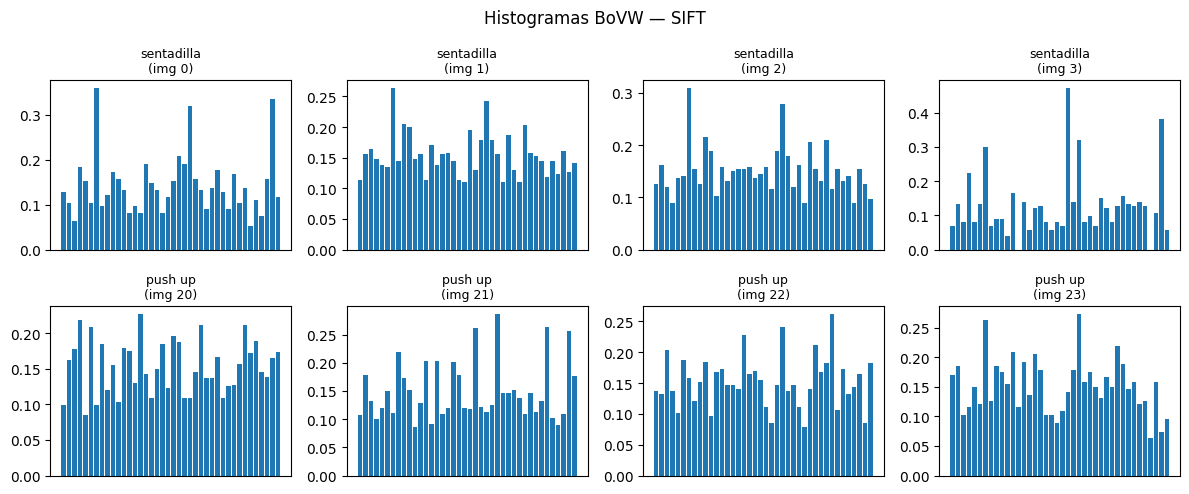

Extractor: HOG  |  X shape: (40, 80)  |  K=80
  X_train: (24, 80)  |  X_test: (16, 80)



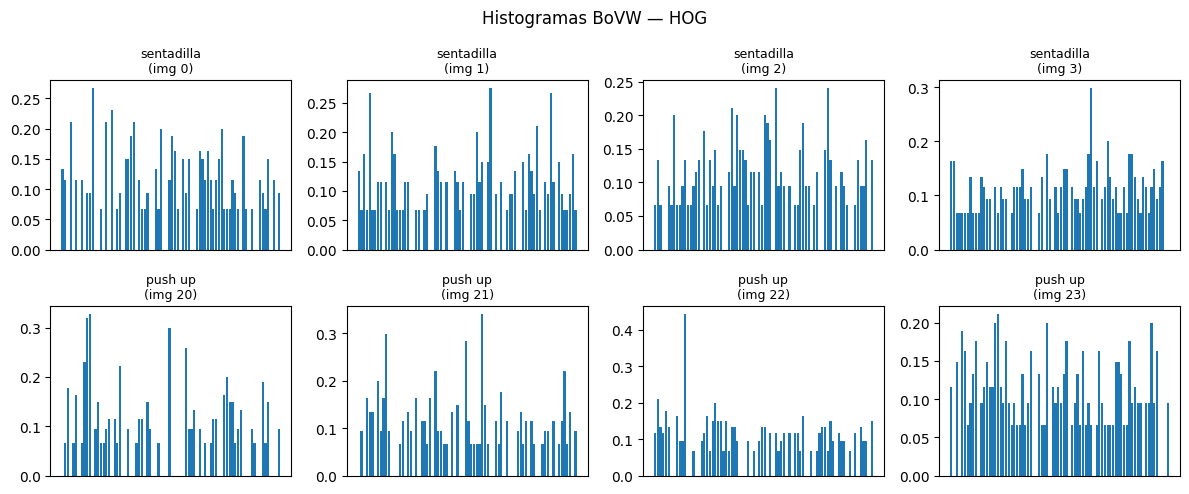

In [12]:
# se codifica cada imagen para ambos extractores

bovw_by_extractor = {}

for extractor_name in all_desc_by_extractor:

    all_desc_list = all_desc_by_extractor[extractor_name]
    kmeans        = kmeans_by_extractor[extractor_name]
    K             = kmeans.n_clusters

    bovw_list = []
    for desc in all_desc_list:
        if len(desc) == 0:
            hist = np.zeros(K, dtype=np.float32)
        else:
            word_ids = kmeans.predict(desc)
            hist = np.bincount(word_ids, minlength=K).astype(np.float32)
        hist = np.sqrt(hist)
        hist = hist / (np.linalg.norm(hist) + 1e-8)
        bovw_list.append(hist)

    X = np.vstack(bovw_list)
    bovw_by_extractor[extractor_name] = X

    print(f"Extractor: {extractor_name.upper()}  |  X shape: {X.shape}  |  K={K}")
    print(f"  X_train: {X[train_idx].shape}  |  X_test: {X[test_idx].shape}\n")

    # histogramas sentadillas
    plt.figure(figsize=(12, 5))
    for i in range(4):
        plt.subplot(2, 4, i + 1)
        plt.bar(np.arange(K), X[i])
        plt.title(f"{labels[i]}\n(img {i})", fontsize=9)
        plt.axis("off") if False else plt.xticks([])

    # histogramas push-ups
    for j in range(4):
        idx = 20 + j
        plt.subplot(2, 4, 4 + j + 1)
        plt.bar(np.arange(K), X[idx])
        plt.title(f"{labels[idx]}\n(img {idx})", fontsize=9)
        plt.xticks([])

    plt.suptitle(f"Histogramas BoVW — {extractor_name.upper()}", fontsize=12)
    plt.tight_layout()
    plt.show()

Extractor usado para BoVW: sift
X total (BoVW): (40, 40)
X_train: (24, 40) | X_test: (16, 40) | K = 40


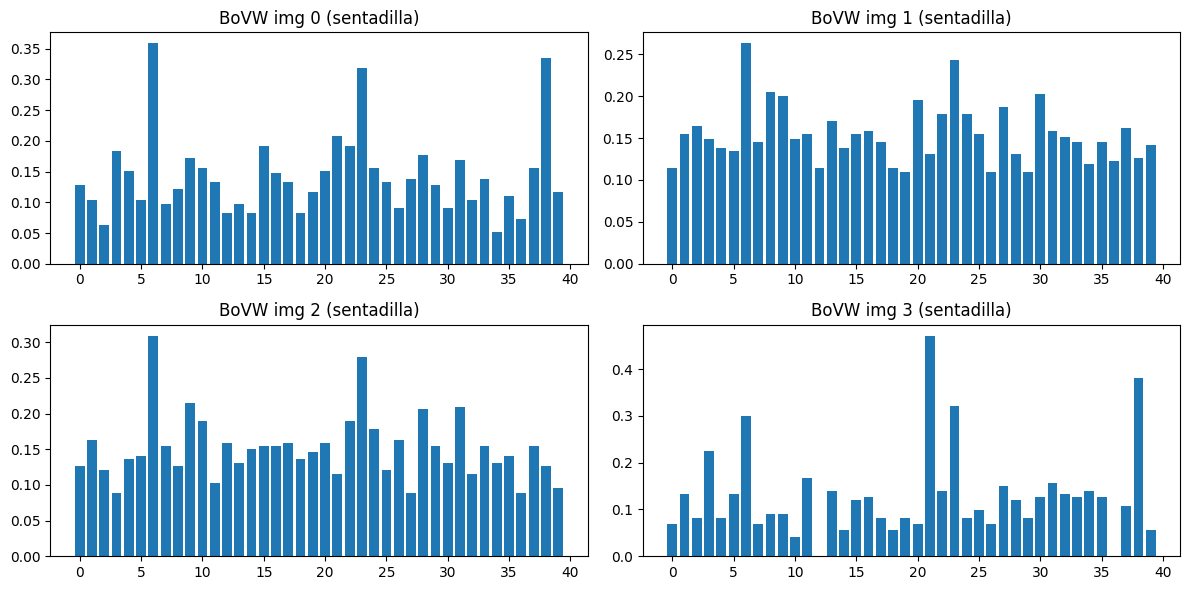

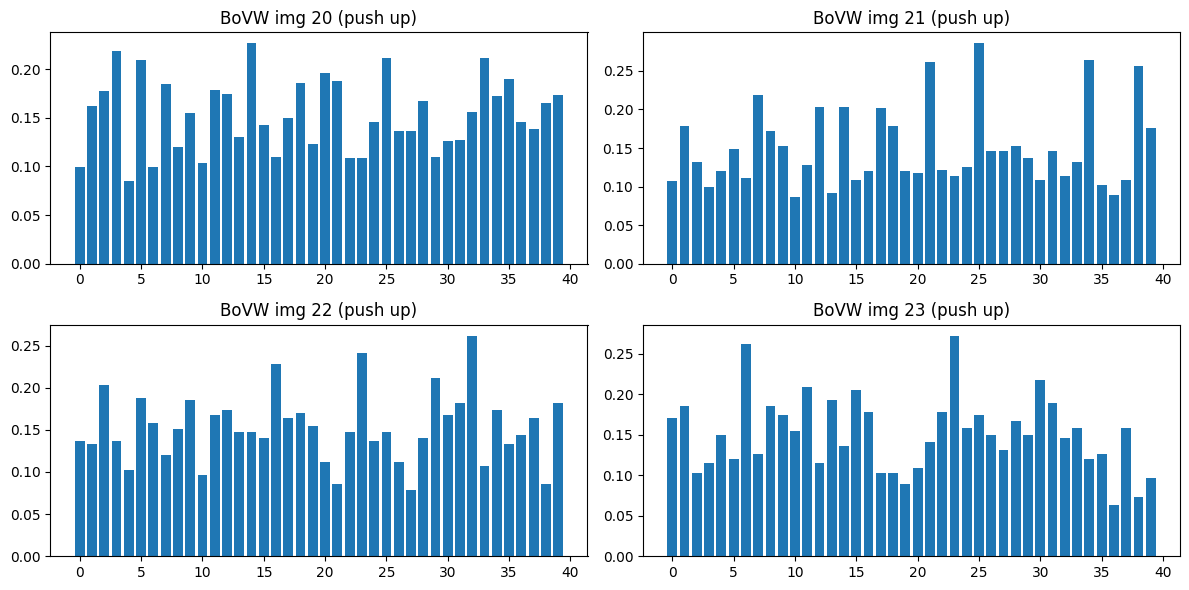

In [ ]:
# bovw_list = [] # Codifica cada imagen como histograma BoVW usando el diccionario aprendido en entrenamiento

# for i, desc in enumerate(all_desc_list):
#     if len(desc) == 0:

#         hist = np.zeros(K, dtype=np.float32)
#     else:
#         word_ids = kmeans.predict(desc)
#         hist = np.bincount(word_ids, minlength=K)
#         hist = hist.astype(np.float32)

#     hist = np.sqrt(hist)
#     norm = np.linalg.norm(hist) + 1e-8
#     hist = hist / norm

#     bovw_list.append(hist)

# X = np.vstack(bovw_list)
# X_train = X[train_idx]
# X_test = X[test_idx]

# print(f"Extractor usado para BoVW: {extractor_for_kmeans}")
# print("X total (BoVW):", X.shape)
# print("X_train:", X_train.shape, "| X_test:", X_test.shape, "| K =", K)

# plt.figure(figsize=(12,6))

# for i in range(4):
#     plt.subplot(2,2,i+1)
#     plt.bar(np.arange(K), X[i])
#     plt.title(f"BoVW img {i} ({labels[i]})")
#     plt.tight_layout()
# plt.show()

# plt.figure(figsize=(12,6))
# for j in range(4):
#     idx = 20 + j
#     plt.subplot(2,2,j+1)
#     plt.bar(np.arange(K), X[idx])
#     plt.title(f"BoVW img {idx} ({labels[idx]})")
#     plt.tight_layout()
# plt.show()

# Clasificación (Laboratorio)

In [ ]:
# CLASIFICACIÓN — SVM lineal y k-NN para ambos extractores

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

classes = sorted(list(set(labels)))
y = np.array(labels)

all_results = {}

for extractor_name in ["sift", "hog"]:

    print(f"\n{'='*50}")
    print(f"  EXTRACTOR: {extractor_name.upper()}")
    print(f"{'='*50}")

    X = bovw_by_extractor[extractor_name]
    y_tr = y[train_idx]
    y_te = y[test_idx]

    # se escalan las features SVM y k-NN son sensibles a la escala
    # fit_transform en train: aprende media y desviación estándar
    # transform en test: aplica la misma escala aprendida (sin recalcular)
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X[train_idx])
    X_test_sc  = scaler.transform(X[test_idx])

    # SVM lineal
    clf_svm = LinearSVC(C=1.0, random_state=42, max_iter=2000)
    clf_svm.fit(X_train_sc, y_tr)
    y_pred_svm = clf_svm.predict(X_test_sc)
    acc_svm = accuracy_score(y_te, y_pred_svm)

    print(f"\nSVM lineal — Accuracy: {acc_svm*100:.2f}%")
    print(classification_report(y_te, y_pred_svm))

    # k-NN
    clf_knn = KNeighborsClassifier(n_neighbors=3)
    clf_knn.fit(X_train_sc, y_tr)
    y_pred_knn = clf_knn.predict(X_test_sc)
    acc_knn = accuracy_score(y_te, y_pred_knn)

    print(f"k-NN — Accuracy: {acc_knn*100:.2f}%")
    print(classification_report(y_te, y_pred_knn))

    all_results[extractor_name] = {
        "svm": {"acc": acc_svm, "y_pred": y_pred_svm},
        "knn": {"acc": acc_knn, "y_pred": y_pred_knn},
        "y_test": y_te,
    }


  EXTRACTOR: SIFT

SVM lineal — Accuracy: 43.75%


c:\Users\julia\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\julia\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


              precision    recall  f1-score   support

     push up       0.45      0.62      0.53         8
  sentadilla       0.40      0.25      0.31         8

    accuracy                           0.44        16
   macro avg       0.43      0.44      0.42        16
weighted avg       0.43      0.44      0.42        16

k-NN — Accuracy: 68.75%
              precision    recall  f1-score   support

     push up       0.71      0.62      0.67         8
  sentadilla       0.67      0.75      0.71         8

    accuracy                           0.69        16
   macro avg       0.69      0.69      0.69        16
weighted avg       0.69      0.69      0.69        16


  EXTRACTOR: HOG

SVM lineal — Accuracy: 62.50%
              precision    recall  f1-score   support

     push up       0.62      0.62      0.62         8
  sentadilla       0.62      0.62      0.62         8

    accuracy                           0.62        16
   macro avg       0.62      0.62      0.62        16
w

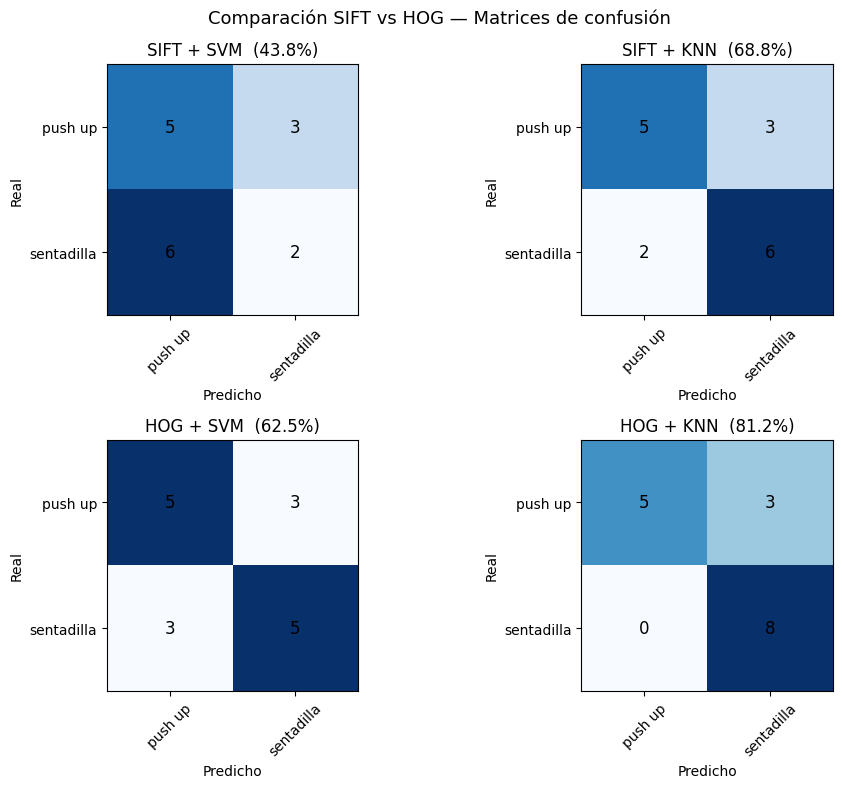


=== RESUMEN FINAL ===
Extractor  Clasificador   Accuracy
----------------------------------
SIFT       SVM              43.75%
SIFT       KNN              68.75%
HOG        SVM              62.50%
HOG        KNN              81.25%


In [14]:
#  Matrices de confusión comparativas para ambos extractores y clasificadores
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Comparación SIFT vs HOG — Matrices de confusión", fontsize=13)

combos = [
    ("sift", "svm", axes[0, 0]),
    ("sift", "knn", axes[0, 1]),
    ("hog",  "svm", axes[1, 0]),
    ("hog",  "knn", axes[1, 1]),
]

for extractor, clf_name, ax in combos:
    r     = all_results[extractor]
    y_pred = r[clf_name]["y_pred"]
    acc    = r[clf_name]["acc"]
    cm = confusion_matrix(r["y_test"], y_pred, labels=classes)

    ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{extractor.upper()} + {clf_name.upper()}  ({acc*100:.1f}%)")
    ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=45)
    ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.show()

# --- Tabla resumen ---
print("\n=== RESUMEN FINAL ===")
print(f"{'Extractor':<10} {'Clasificador':<12} {'Accuracy':>10}")
print("-" * 34)
for extractor in ["sift", "hog"]:
    for clf_name in ["svm", "knn"]:
        acc = all_results[extractor][clf_name]["acc"]
        print(f"{extractor.upper():<10} {clf_name.upper():<12} {acc*100:>9.2f}%")

In [ ]:
# clf = LinearSVC(C=1.0, random_state=42)
# clf.fit(X_train, y_train)
# y_pred = clf.predict(X_test)

# acc = accuracy_score(y_test, y_pred)

# print("Accuracy (SVM lineal):", f"{acc*100:.2f}%")
# print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

# classes = sorted(list(set(y)))
# cm = confusion_matrix(y_test, y_pred, labels=classes)

# plt.figure(figsize=(4,4))
# plt.imshow(cm, cmap='Blues')
# plt.title("Matriz de confusión")
# plt.xticks(range(len(classes)), classes, rotation=45)
# plt.yticks(range(len(classes)), classes)

# for i in range(cm.shape[0]):
#     for j in range(cm.shape[1]):
#         plt.text(j, i, cm[i,j], ha='center', va='center')

# plt.xlabel("Predicho")
# plt.ylabel("Real")
# plt.tight_layout()
# plt.show()

NameError: name 'X_train' is not defined